# argentina.postal — Códigos postales en la práctica

Recorrido **usando el paquete** sobre casos típicos de un dataset con códigos postales argentinos:

1. Limpiar entradas sucias del mundo real.
2. Discriminar CP4 vs CPA.
3. Enriquecer con provincia/región/capital usando `argentina.provincias`.
4. Detectar inconsistencias entre CP declarado y provincia declarada.
5. Resumir distribución de un lote.

Todo es sintáctico — no hace red ni valida que el código exista en el territorio.

## 1. Setup

In [1]:
import argentina as arg
import pandas as pd

print(f"argentina v{arg.__version__}")

argentina v0.0.14


## 2. Letras CPA por provincia

El primer carácter del CPA identifica la jurisdicción postal.

In [2]:
tabla = pd.DataFrame(
    sorted(arg.postal.CPA_PROVINCIAS.items()),
    columns=['letra', 'provincia'],
)
tabla

,letra,provincia
0,A,Salta
1,B,Buenos Aires
2,C,Ciudad Autónoma de Buenos Aires
3,D,San Luis
4,E,Entre Ríos
5,F,La Rioja
6,G,Santiago del Estero
7,H,Chaco
8,J,San Juan
9,K,Catamarca


## 3. Limpiar entradas sucias

Un dataset típico viene con espacios, símbolos, mayúsculas mezcladas, etc. `limpiar_codigo_postal` normaliza antes de cualquier otro chequeo.

In [3]:
sucios = [
    " c1425 abc ",
    "1425",
    "X5000AAA",
    "  1425  ",
    "c1425-abc",
    "X 5000 AAA",
    "abc",
    "",
    None,
    12345,
]

df = pd.DataFrame({'entrada': sucios})
df['limpio'] = df['entrada'].apply(arg.postal.limpiar_codigo_postal)
df['tipo']   = df['entrada'].apply(arg.postal.tipo_codigo_postal)
df

,entrada,limpio,tipo
0,c1425 abc,C1425ABC,cpa
1,1425,1425,cp4
2,X5000AAA,X5000AAA,cpa
3,1425,1425,cp4
4,c1425-abc,C1425ABC,cpa
5,X 5000 AAA,X5000AAA,cpa
6,abc,ABC,None
7,,None,None
8,None,None,None
9,12345,12345,None


## 4. De CPA a CP4 (y viceversa)

Muchos sistemas viejos siguen usando los 4 dígitos. `extraer_cp4` toma cualquiera de los dos formatos.

In [4]:
mezclados = ['C1425ABC', '1425', 'X5000AAA', 'S2000ABC', 'B1900CKC', '8400']

df = pd.DataFrame({'codigo': mezclados})
df['tipo'] = df['codigo'].apply(arg.postal.tipo_codigo_postal)
df['cp4']  = df['codigo'].apply(arg.postal.extraer_cp4)
df

,codigo,tipo,cp4
0,C1425ABC,cpa,1425
1,1425,cp4,1425
2,X5000AAA,cpa,5000
3,S2000ABC,cpa,2000
4,B1900CKC,cpa,1900
5,8400,cp4,8400


## 5. Enriquecer con metadata de provincia

A partir de la letra inicial del CPA conocemos la provincia. Cruzando con `argentina.provincias` agregamos región y capital.

In [5]:
# CPAs sintéticos pero representativos: capital postal de cada provincia
capitales_cpa = [
    'C1000AAA',  # CABA
    'B1900AAA',  # La Plata
    'X5000AAA',  # Córdoba
    'S2000AAA',  # Santa Fe
    'M5500AAA',  # Mendoza
    'T4000AAA',  # Tucumán
    'Q8300AAA',  # Neuquén
    'A4400AAA',  # Salta
    'V9410AAA',  # Tierra del Fuego
    'Z9400AAA',  # Santa Cruz
]

def enriquecer(cpa):
    prov_nombre = arg.postal.provincia_por_cpa(cpa)
    if prov_nombre is None:
        return None, None, None
    p = arg.provincias.lookup(prov_nombre)
    return p.nombre, p.region, p.capital

df = pd.DataFrame({'cpa': capitales_cpa})
df['letra']     = df['cpa'].apply(arg.postal.letra_provincia)
df['provincia'] = df['cpa'].apply(lambda c: enriquecer(c)[0])
df['region']    = df['cpa'].apply(lambda c: enriquecer(c)[1])
df['capital']   = df['cpa'].apply(lambda c: enriquecer(c)[2])
df

,cpa,letra,provincia,region,capital
0,C1000AAA,C,Ciudad Autónoma de Buenos Aires,CABA,Ciudad Autónoma de Buenos Aires
1,B1900AAA,B,Buenos Aires,Pampeana,La Plata
2,X5000AAA,X,Córdoba,Pampeana,Córdoba
3,S2000AAA,S,Santa Fe,Pampeana,Santa Fe
4,M5500AAA,M,Mendoza,Cuyo,Mendoza
5,T4000AAA,T,Tucumán,NOA,San Miguel de Tucumán
6,Q8300AAA,Q,Neuquén,Patagonia,Neuquén
7,A4400AAA,A,Salta,NOA,Salta
8,V9410AAA,V,Tierra del Fuego,Patagonia,Ushuaia
9,Z9400AAA,Z,Santa Cruz,Patagonia,Río Gallegos


## 6. Detectar inconsistencias

Caso típico: un formulario te pide CP y provincia por separado. `validar_cpa_provincia` flaggea cuando no coinciden.

In [6]:
envios = pd.DataFrame([
    {'cpa': 'C1425ABC', 'provincia_declarada': 'CABA'},
    {'cpa': 'X5000AAA', 'provincia_declarada': 'Córdoba'},
    {'cpa': 'X5000AAA', 'provincia_declarada': 'Buenos Aires'},  # mal
    {'cpa': 'B1900AAA', 'provincia_declarada': 'PBA'},            # alias
    {'cpa': 'S2000AAA', 'provincia_declarada': 'santa fe'},       # case-insensitive
    {'cpa': 'M5500AAA', 'provincia_declarada': 'Mendoza'},
    {'cpa': '1425',     'provincia_declarada': 'Buenos Aires'},   # CP4 no tiene letra → false
])

envios['ok'] = envios.apply(
    lambda r: arg.postal.validar_cpa_provincia(r['cpa'], r['provincia_declarada']),
    axis=1,
)
envios

,cpa,provincia_declarada,ok
0,C1425ABC,CABA,True
1,X5000AAA,Córdoba,True
2,X5000AAA,Buenos Aires,False
3,B1900AAA,PBA,True
4,S2000AAA,santa fe,True
5,M5500AAA,Mendoza,True
6,1425,Buenos Aires,False


## 7. Distribución de un lote

Dado un conjunto de CPAs, contamos cuántos hay por provincia y región.

In [7]:
import random
random.seed(42)

# Generamos 500 CPAs simulando una concentración fuerte en CABA/PBA y resto disperso
pesos = {'C': 35, 'B': 30, 'X': 8, 'S': 7, 'M': 4, 'T': 3, 'A': 2}
todos = list(arg.postal.CPA_PROVINCIAS.keys())
for letra in todos:
    pesos.setdefault(letra, 1)

letras = random.choices(todos, weights=[pesos[l] for l in todos], k=500)
cpas = [f"{l}{random.randint(1000, 9999)}AAA" for l in letras]

lote = pd.DataFrame({'cpa': cpas})
lote['provincia'] = lote['cpa'].apply(arg.postal.provincia_por_cpa)
lote['region']    = lote['provincia'].apply(lambda p: arg.provincias.lookup(p).region if p else None)

lote['provincia'].value_counts().head(10)

provincia
Buenos Aires                       153
Ciudad Autónoma de Buenos Aires    151
Córdoba                             32
Santa Fe                            30
Tucumán                             19
Mendoza                             18
San Luis                            10
Corrientes                          10
Salta                               10
Chaco                                8
Name: count, dtype: int64

In [8]:
# Resumen por región
lote['region'].value_counts()

region
Pampeana     222
CABA         151
NOA           46
Cuyo          30
NEA           26
Patagonia     25
Name: count, dtype: int64

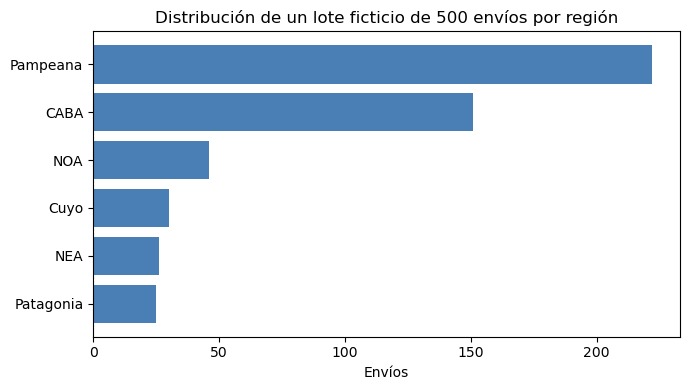

In [9]:
import matplotlib.pyplot as plt

by_region = lote['region'].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(by_region.index, by_region.values, color='#4a7fb5')
ax.set_xlabel('Envíos')
ax.set_title('Distribución de un lote ficticio de 500 envíos por región')
plt.tight_layout()
plt.show()

## 8. `argentina.geo.postal` (todavía sin implementar)

La parte georreferencial (mapear CP a polígono, validar contra un municipio real) vive en el subpaquete `geo.postal`. Por ahora son placeholders explícitos: si los llamás, tiran `NotImplementedError` con un mensaje claro.

In [10]:
from argentina.geo import postal as geo_postal

for fn in [
    geo_postal.georreferenciar_codigo_postal,
    geo_postal.codigo_postal_por_direccion,
    geo_postal.validar_codigo_postal_municipio,
]:
    try:
        fn('C1425ABC')
    except NotImplementedError as e:
        print(f"{fn.__name__}:")
        print(f"   {e}")
        print()

georreferenciar_codigo_postal:
   argentina.geo.postal.georreferenciar_codigo_postal todavía no está implementado. La validación sintáctica vive en argentina.postal.

codigo_postal_por_direccion:
   argentina.geo.postal.codigo_postal_por_direccion todavía no está implementado. Para direcciones se recomienda usar una fuente oficial o Georef para coordenadas.

validar_codigo_postal_municipio:
   argentina.geo.postal.validar_codigo_postal_municipio todavía no está implementado. Requiere una base territorial postal confiable.

